In [91]:
import pandas as pd
df = pd.read_csv('/content/Used Car Price Prediction.csv')

In [92]:
df.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [93]:
df.drop(['Unnamed: 0', 'Location', 'New_Price'], axis=1, inplace=True)

In [94]:
df.head()

,Name,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
2,Honda Jazz V,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50
3,Maruti Ertiga VDI,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74


In [95]:
df.isnull().sum()

,0
Name,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,2
Engine,36
Power,36
Seats,42


In [96]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Year               6019 non-null   int64  
 2   Kilometers_Driven  6019 non-null   int64  
 3   Fuel_Type          6019 non-null   object 
 4   Transmission       6019 non-null   object 
 5   Owner_Type         6019 non-null   object 
 6   Mileage            6017 non-null   object 
 7   Engine             5983 non-null   object 
 8   Power              5983 non-null   object 
 9   Seats              5977 non-null   float64
 10  Price              6019 non-null   float64
dtypes: float64(2), int64(2), object(7)
memory usage: 517.4+ KB


In [98]:
# Removeing units from Mileage
df["Mileage"] = df["Mileage"].str.replace(" kmpl", "", regex=False)
df["Mileage"] = df["Mileage"].str.replace(" km/kg", "", regex=False)

# Removeing units from Engine
df["Engine"] = df["Engine"].str.replace(" CC", "", regex=False)

# Removeing units from Power
df["Power"] = df["Power"].str.replace(" bhp", "", regex=False)

# Converting to numeric
df["Mileage"] = pd.to_numeric(df["Mileage"], errors="coerce")
df["Engine"] = pd.to_numeric(df["Engine"], errors="coerce")
df["Power"] = pd.to_numeric(df["Power"], errors="coerce")

In [99]:
# Filling missing values with median
df["Mileage"] = df["Mileage"].fillna(df["Mileage"].median())

df["Engine"] = df["Engine"].fillna(df["Engine"].median())

df["Power"] = df["Power"].fillna(df["Power"].median())

df["Seats"] = df["Seats"].fillna(df["Seats"].median())

In [100]:
current_year = 2026

df["Car_Age"] = current_year - df["Year"]
df.drop("Year", axis=1, inplace=True)

In [101]:
df.head()

,Name,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Car_Age
0,Maruti Wagon R LXI CNG,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75,16
1,Hyundai Creta 1.6 CRDi SX Option,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,11
2,Honda Jazz V,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50,15
3,Maruti Ertiga VDI,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00,14
4,Audi A4 New 2.0 TDI Multitronic,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,13


In [102]:
# Extracting brand from car name
df["Brand"] = df["Name"].str.split().str[0]
df.drop("Name", axis=1, inplace=True)

In [103]:
# Displaying all categorical columns
df.select_dtypes(include="object").columns

Index(['Fuel_Type', 'Transmission', 'Owner_Type', 'Brand'], dtype='object')

In [104]:
# Displaying all categorical columns
df.select_dtypes(include="object").columns

Index(['Fuel_Type', 'Transmission', 'Owner_Type', 'Brand'], dtype='object')

In [105]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Fuel_Type"] = encoder.fit_transform(df["Fuel_Type"])
df["Transmission"] = encoder.fit_transform(df["Transmission"])
df["Owner_Type"] = encoder.fit_transform(df["Owner_Type"])
df["Brand"] = encoder.fit_transform(df["Brand"])

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Kilometers_Driven  6019 non-null   int64  
 1   Fuel_Type          6019 non-null   int64  
 2   Transmission       6019 non-null   int64  
 3   Owner_Type         6019 non-null   int64  
 4   Mileage            6019 non-null   float64
 5   Engine             6019 non-null   float64
 6   Power              6019 non-null   float64
 7   Seats              6019 non-null   float64
 8   Price              6019 non-null   float64
 9   Car_Age            6019 non-null   int64  
 10  Brand              6019 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 517.4 KB


In [107]:
df.describe()

,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Car_Age,Brand
count,6.019000e+03,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000,6019.000000
mean,5.873838e+04,2.363017,0.714238,0.379465,18.134966,1620.509221,112.883539,5.276790,9.479468,12.641801,15.332281
std,9.126884e+04,1.504939,0.451814,0.818458,4.581528,599.635458,53.283701,0.806346,11.187917,3.269742,8.052311
min,1.710000e+02,0.000000,0.000000,0.000000,0.000000,72.000000,34.200000,0.000000,0.440000,7.000000,0.000000
25%,3.400000e+04,1.000000,0.000000,0.000000,15.170000,1198.000000,78.000000,5.000000,3.500000,10.000000,9.000000
50%,5.300000e+04,1.000000,1.000000,0.000000,18.150000,1493.000000,97.700000,5.000000,5.640000,12.000000,17.000000
75%,7.300000e+04,4.000000,1.000000,0.000000,21.100000,1969.000000,138.030000,5.000000,9.950000,15.000000,19.000000
max,6.500000e+06,4.000000,1.000000,3.000000,33.540000,5998.000000,560.000000,10.000000,160.000000,28.000000,30.000000


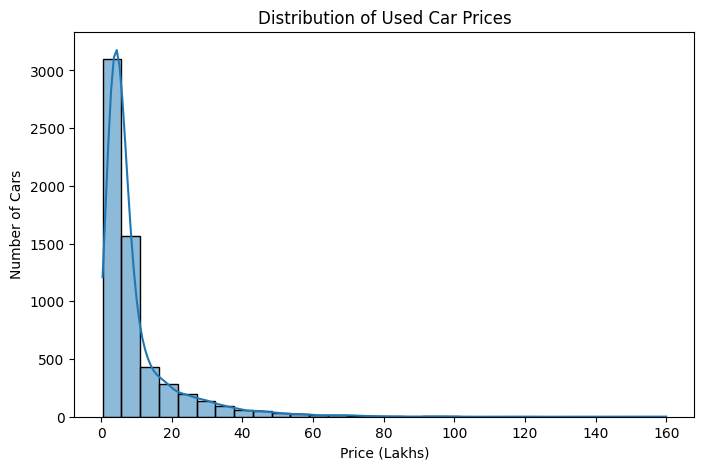

In [108]:
#Price Distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))

sns.histplot(df["Price"], bins=30, kde=True)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Cars")

plt.show()

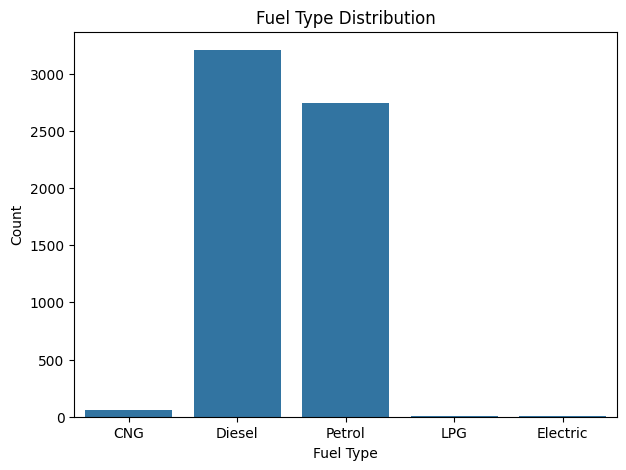

In [109]:
#Fuel Type Distribution
fuel_mapping = {
    0: "CNG",
    1: "Diesel",
    2: "Electric",
    3: "LPG",
    4: "Petrol"
}

plt.figure(figsize=(7,5))

sns.countplot(x=df["Fuel_Type"].map(fuel_mapping))

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")

plt.show()

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Kilometers_Driven  6019 non-null   int64  
 1   Fuel_Type          6019 non-null   int64  
 2   Transmission       6019 non-null   int64  
 3   Owner_Type         6019 non-null   int64  
 4   Mileage            6019 non-null   float64
 5   Engine             6019 non-null   float64
 6   Power              6019 non-null   float64
 7   Seats              6019 non-null   float64
 8   Price              6019 non-null   float64
 9   Car_Age            6019 non-null   int64  
 10  Brand              6019 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 517.4 KB


In [111]:
# Features
X = df.drop("Price", axis=1)

# Target
y = df["Price"]

In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (4815, 10)
Testing Data : (1204, 10)


In [113]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [114]:
lr_pred = lr.predict(X_test)

In [115]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Linear Regression Performance")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R² Score:", r2_score(y_test, lr_pred))

Linear Regression Performance
MAE : 4.0191882278645075
RMSE: 8.013398594575898
R² Score: 0.47818281997081413


In [116]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Decision Tree Performance")
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R² Score:", r2_score(y_test, dt_pred))

Decision Tree Performance
MAE : 2.108289036544851
RMSE: 5.472262915857185
R² Score: 0.7566570366937081


In [117]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
print("Random Forest Performance")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R² Score:", r2_score(y_test, rf_pred))

Random Forest Performance
MAE : 1.7061586044534094
RMSE: 4.109191081691792
R² Score: 0.86278627445898


In [118]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

print(results)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  4.019188  8.013399  0.478183
1      Decision Tree  2.108289  5.472263  0.756657
2      Random Forest  1.706159  4.109191  0.862786


In [119]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoder.fit(df["Brand"])

for code, brand in enumerate(encoder.classes_):
    print(code, ":", brand)

0 : 0
1 : 1
2 : 2
3 : 3
4 : 4
5 : 5
6 : 6
7 : 7
8 : 8
9 : 9
10 : 10
11 : 11
12 : 12
13 : 13
14 : 14
15 : 15
16 : 16
17 : 17
18 : 18
19 : 19
20 : 20
21 : 21
22 : 22
23 : 23
24 : 24
25 : 25
26 : 26
27 : 27
28 : 28
29 : 29
30 : 30


In [125]:
# USED CAR PRICE PREDICTION SYSTEM



# Brand Options
brand_options = {
    0: "Maruti",
    1: "Hyundai",
    2: "Honda",
    3: "Toyota",
    4: "Mahindra",
    5: "Tata",
    6: "Ford",
    7: "BMW",
    8: "Audi",
    9: "Mercedes-Benz"
}

print("\nAVAILABLE CAR BRANDS ")
for key, value in brand_options.items():
    print(f"{key} : {value}")

while True:
    brand = int(input("\nEnter Brand Code: "))
    if brand in brand_options:
        break
    print(" Invalid Brand Code! Please try again.")


# Fuel Type
fuel_options = {
    0: "CNG",
    1: "Diesel",
    2: "Electric",
    3: "LPG",
    4: "Petrol"
}

print("\nFUEL TYPES")
for key, value in fuel_options.items():
    print(f"{key} : {value}")

while True:
    fuel = int(input("\nEnter Fuel Type: "))
    if fuel in fuel_options:
        break
    print(" Invalid Fuel Type!")


# Transmission
transmission_options = {
    0: "Automatic",
    1: "Manual"
}

print("\n TRANSMISSION ")
for key, value in transmission_options.items():
    print(f"{key} : {value}")

while True:
    transmission = int(input("\nEnter Transmission: "))
    if transmission in transmission_options:
        break
    print(" Invalid Transmission!")


# Owner Type
owner_options = {
    0: "First Owner",
    1: "Second Owner",
    2: "Third Owner",
    3: "Fourth & Above"
}

print("\n OWNER TYPE ")
for key, value in owner_options.items():
    print(f"{key} : {value}")

while True:
    owner = int(input("\nEnter Owner Type: "))
    if owner in owner_options:
        break
    print(" Invalid Owner Type!")


# Kilometers Driven
while True:
    km = float(input("\nEnter Kilometers Driven (0 - 10,00,000): "))
    if 0 <= km <= 1000000:
        break
    print(" Invalid value!")


# Mileage
while True:
    mileage = float(input("Enter Mileage (5 - 40 kmpl): "))
    if 5 <= mileage <= 40:
        break
    print(" Mileage should be between 5 and 40 kmpl.")


# Engine
while True:
    engine = float(input("Enter Engine Capacity (600 - 5000 CC): "))
    if 600 <= engine <= 5000:
        break
    print(" Engine capacity should be between 600 and 5000 CC.")


# Power
while True:
    power = float(input("Enter Power (30 - 700 BHP): "))
    if 30 <= power <= 700:
        break
    print(" Power should be between 30 and 700 BHP.")


# Seats
while True:
    seats = int(input("Enter Number of Seats (2 - 9): "))
    if 2 <= seats <= 9:
        break
    print(" Seats should be between 2 and 9.")


# Car Age
while True:
    age = int(input("Enter Car Age (0 - 30 Years): "))
    if 0 <= age <= 30:
        break
    print(" Car age should be between 0 and 30 years.")


# Prepare Data for Prediction
car_data = [[
    km,
    fuel,
    transmission,
    owner,
    mileage,
    engine,
    power,
    seats,
    age,
    brand
]]


# Predict Price
predicted_price = rf.predict(car_data)

# Display Result
print("        USED CAR PRICE PREDICTION")

print(f"Brand              : {brand_options[brand]}")
print(f"Fuel Type          : {fuel_options[fuel]}")
print(f"Transmission       : {transmission_options[transmission]}")
print(f"Owner Type         : {owner_options[owner]}")
print(f"Kilometers Driven  : {km:,.0f} km")
print(f"Mileage            : {mileage} kmpl")
print(f"Engine Capacity    : {engine} CC")
print(f"Power              : {power} BHP")
print(f"Seats              : {seats}")
print(f"Car Age            : {age} Years")
print(f"Estimated Price    : ₹ {predicted_price[0]:.2f} Lakhs")



AVAILABLE CAR BRANDS 
0 : Maruti
1 : Hyundai
2 : Honda
3 : Toyota
4 : Mahindra
5 : Tata
6 : Ford
7 : BMW
8 : Audi
9 : Mercedes-Benz

Enter Brand Code: 32
 Invalid Brand Code! Please try again.

Enter Brand Code: 32
 Invalid Brand Code! Please try again.

Enter Brand Code: 2

FUEL TYPES
0 : CNG
1 : Diesel
2 : Electric
3 : LPG
4 : Petrol

Enter Fuel Type: 516
 Invalid Fuel Type!

Enter Fuel Type: 3

 TRANSMISSION 
0 : Automatic
1 : Manual

Enter Transmission: 6
 Invalid Transmission!

Enter Transmission: 1

 OWNER TYPE 
0 : First Owner
1 : Second Owner
2 : Third Owner
3 : Fourth & Above

Enter Owner Type: 3

Enter Kilometers Driven (0 - 10,00,000): 01
Enter Mileage (5 - 40 kmpl): 25
Enter Engine Capacity (600 - 5000 CC): 600
Enter Power (30 - 700 BHP): 32
Enter Number of Seats (2 - 9): 5
Enter Car Age (0 - 30 Years): 6
        USED CAR PRICE PREDICTION
Brand              : Honda
Fuel Type          : LPG
Transmission       : Manual
Owner Type         : Fourth & Above
Kilometers Driven  :

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
